# Les langage des jeunes sur les réseaux sociaux obéit-il à un principe d’économie linguistique ? #

**Auteur** : Georges BONDANELLI


**Date** : Mai 2026

## **0. Bibliothèques**

In [ ]:
import pandas as pd # Importation bibliothèques
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

## **1. Introduction**

Les réseaux sociaux ont profondément transformé les pratiques d’écriture. Les commentaires publiés sur des plateformes numériques présentent souvent des formes linguistiques s’écartant de la norme écrite traditionnelle : abréviations, écriture phonétique, suppression d’éléments syntaxiques ou recours aux emojis.

Ces pratiques sont parfois interprétées comme un appauvrissement de la langue. Une autre hypothèse consiste cependant à considérer ces phénomènes comme une **adaptation aux contraintes du médium numérique** : rapidité d’écriture, instantanéité des échanges, contraintes attentionnelles ou recherche d’efficacité communicationnelle.

Plusieurs travaux en linguistique quantitative suggèrent que les systèmes de communication tendent à optimiser le rapport entre coût de production et efficacité communicative. La **loi d’abréviation de Zipf** (« *Zipf’s Law of Abbreviation* ») propose par exemple que les unités linguistiques les plus fréquentes tendent à être plus courtes ou plus simples. Des recherches récentes ont montré que ce principe s’observe également au niveau des caractères dans différents systèmes d’écriture (Koshevoy, Miton & Morin, 2023).

Dans cette perspective, les pratiques linguistiques observées sur les réseaux sociaux peuvent être interprétées non comme une dégradation de la langue, mais comme une adaptation à un environnement communicationnel spécifique.

Dans ce projet, l’**économie linguistique** est définie comme :

> l’ensemble des procédés permettant de réduire l’effort de production d’un message tout en conservant son efficacité communicative.

L’objectif n’est donc pas d’évaluer une qualité ou une dégradation de la langue, mais d’**identifier et quantifier certains procédés linguistiques participant à une logique d’économie.**

## **2. Données**

Le corpus utilisé est constitué de commentaires TikTok obtenus par **scraping** avec Apify et **annotation automatique par un LLM** (code de l'annotation avec instructions sur github). Le corpus contient environ 2500 (2119 après nettoyage) commentaires principalement francophones et anglophone, associés à des contenus attirant un public jeune. Chaque commentaire a été annoté selon plusieurs catégories linguistiques.

| variable                    | signification                                                                           |
| --------------------------- | --------------------------------------------------------------------------------------- |
| `comment_id`                | identifiant unique associé à chaque commentaire                                         |
| `comment_text`              | contenu textuel du commentaire                                                          |
| `language`                  | langue détectée du commentaire                                                          |
| `abbreviation_words`        | présence d’abréviations ou de formes réduites (ex. : *jsp*, *tkt*, *mdr*)               |
| `syntax_suppression`        | présence d’une réduction de structure syntaxique (suppression du sujet, du verbe, etc.) |
| `phonetic_writing`          | présence d’une écriture proche de l’oral (ex. : *chui*, *oe*, *wsh*)                    |
| `emoji_replaces_text`       | présence d’un emoji remplaçant une unité textuelle ou pragmatique                       |
| `letter_repetition_emotion` | présence de répétitions graphiques expressives (ex. : *mdrrrrr*, *quoiiiii*)            |




In [2]:
df=pd.read_csv("comments_annotated.csv") # Chargement

df=df.dropna() # Suppression valeurs manquantes
df=df.drop_duplicates()

df["nb_caracteres"]=df["comment_text"].str.len() # Longueur commentaires
df["nb_mots"]=df["comment_text"].str.split().str.len()

df = df[df["nb_mots"] <= 200] # Supression des commentaires de plus de 200 mots

print("Après :", len(df)) # Nombre après suppression

Après : 2119


In [3]:
df.head()

,comment_id,comment_text,language;,abbreviation_words,syntax_suppression,phonetic_writing,emoji_replaces_text,letter_repetition_emotion,nb_caracteres,nb_mots
0,6926244632611602437,I’ve never replayed a video so much,en;,True,False,False,False,False,35,7
1,7642573151024628488,[Sticker] me:,sticker;,False,False,False,False,False,13,2
2,7619497589889467159,i didn’t even need to read the bio to believe ...,en;,False,False,False,False,False,74,16
3,7496165632699237142,😂😂😂 I'm easily amused 👀😂❤️❤️,en;,True,False,False,True,False,28,5
4,7608267264773341970,I need romantic bestie,en;,False,True,False,False,False,22,4


Pour l'analyse nous créons deux variables : nombre de caractères et nombre de mots. Et nous intégrons un Indice d'Economie Linguistique (IEL) qui est calculé comme suit : 
$$
IEL = \frac{A + S + P + E}{4}
$$
avec :
- $A$ : présence d'abréviations
- $S$ : suppression syntaxique
- $P$ : écriture phonétique
- $E$ : emoji remplaçant une unité textuelle

La variable « répétition expressive » ne sera pas intégrée à l’indice principal d’économie linguistique, car elle n’implique pas nécessairement une réduction du coût de production ; elle sera étudiée séparément comme phénomène d’expressivité numérique.

In [4]:
df["IEL"]=( # Création de la variable IEL
df["abbreviation_words"]
+df["syntax_suppression"]
+df["phonetic_writing"]
+df["emoji_replaces_text"]
)/4

## **3. Analyse**

### 3.1 Exemple qualitatif

Pour mieux comprendre les enjeux linguistiques des procédés choisis, voici des exemples parlants avant de se lancer dans les statistiques.

"Att t sérieux 💀"

- "Att" : abreviation
- "t" : suppression syntaxique et écriture phonétique
- "💀" : emoji remplaçant une réaction discursive


"mdrrrrrrrr"

- réduction initiale ("mdr") 
- répétition expressive 
- compensation de l’absence d’intonation

Ces exemples montrent que la réduction formelle ne correspond pas nécessairement à une réduction informationnelle.

### 3.2 Analyse descriptive

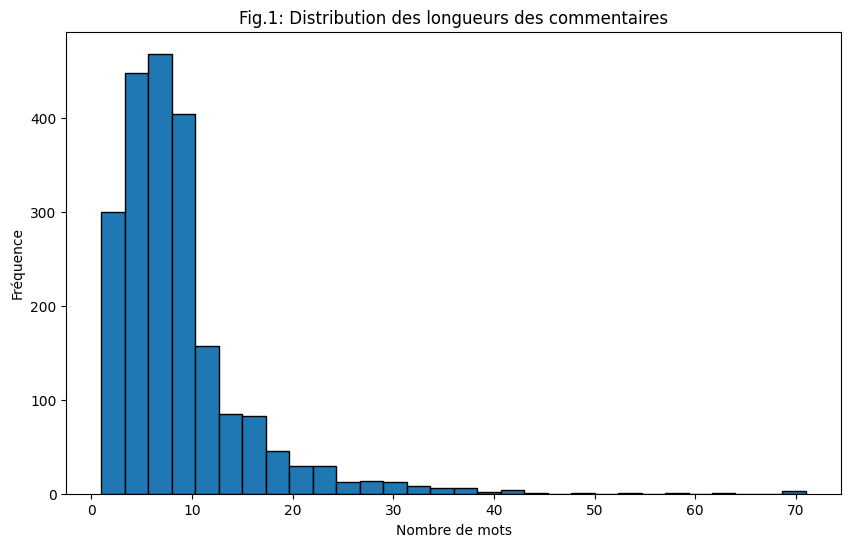

In [11]:
plt.figure(figsize=(10,6)) # Graphique 1

plt.hist(
    df["nb_mots"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.title("Fig.1: Distribution des longueurs des commentaires")

plt.show()

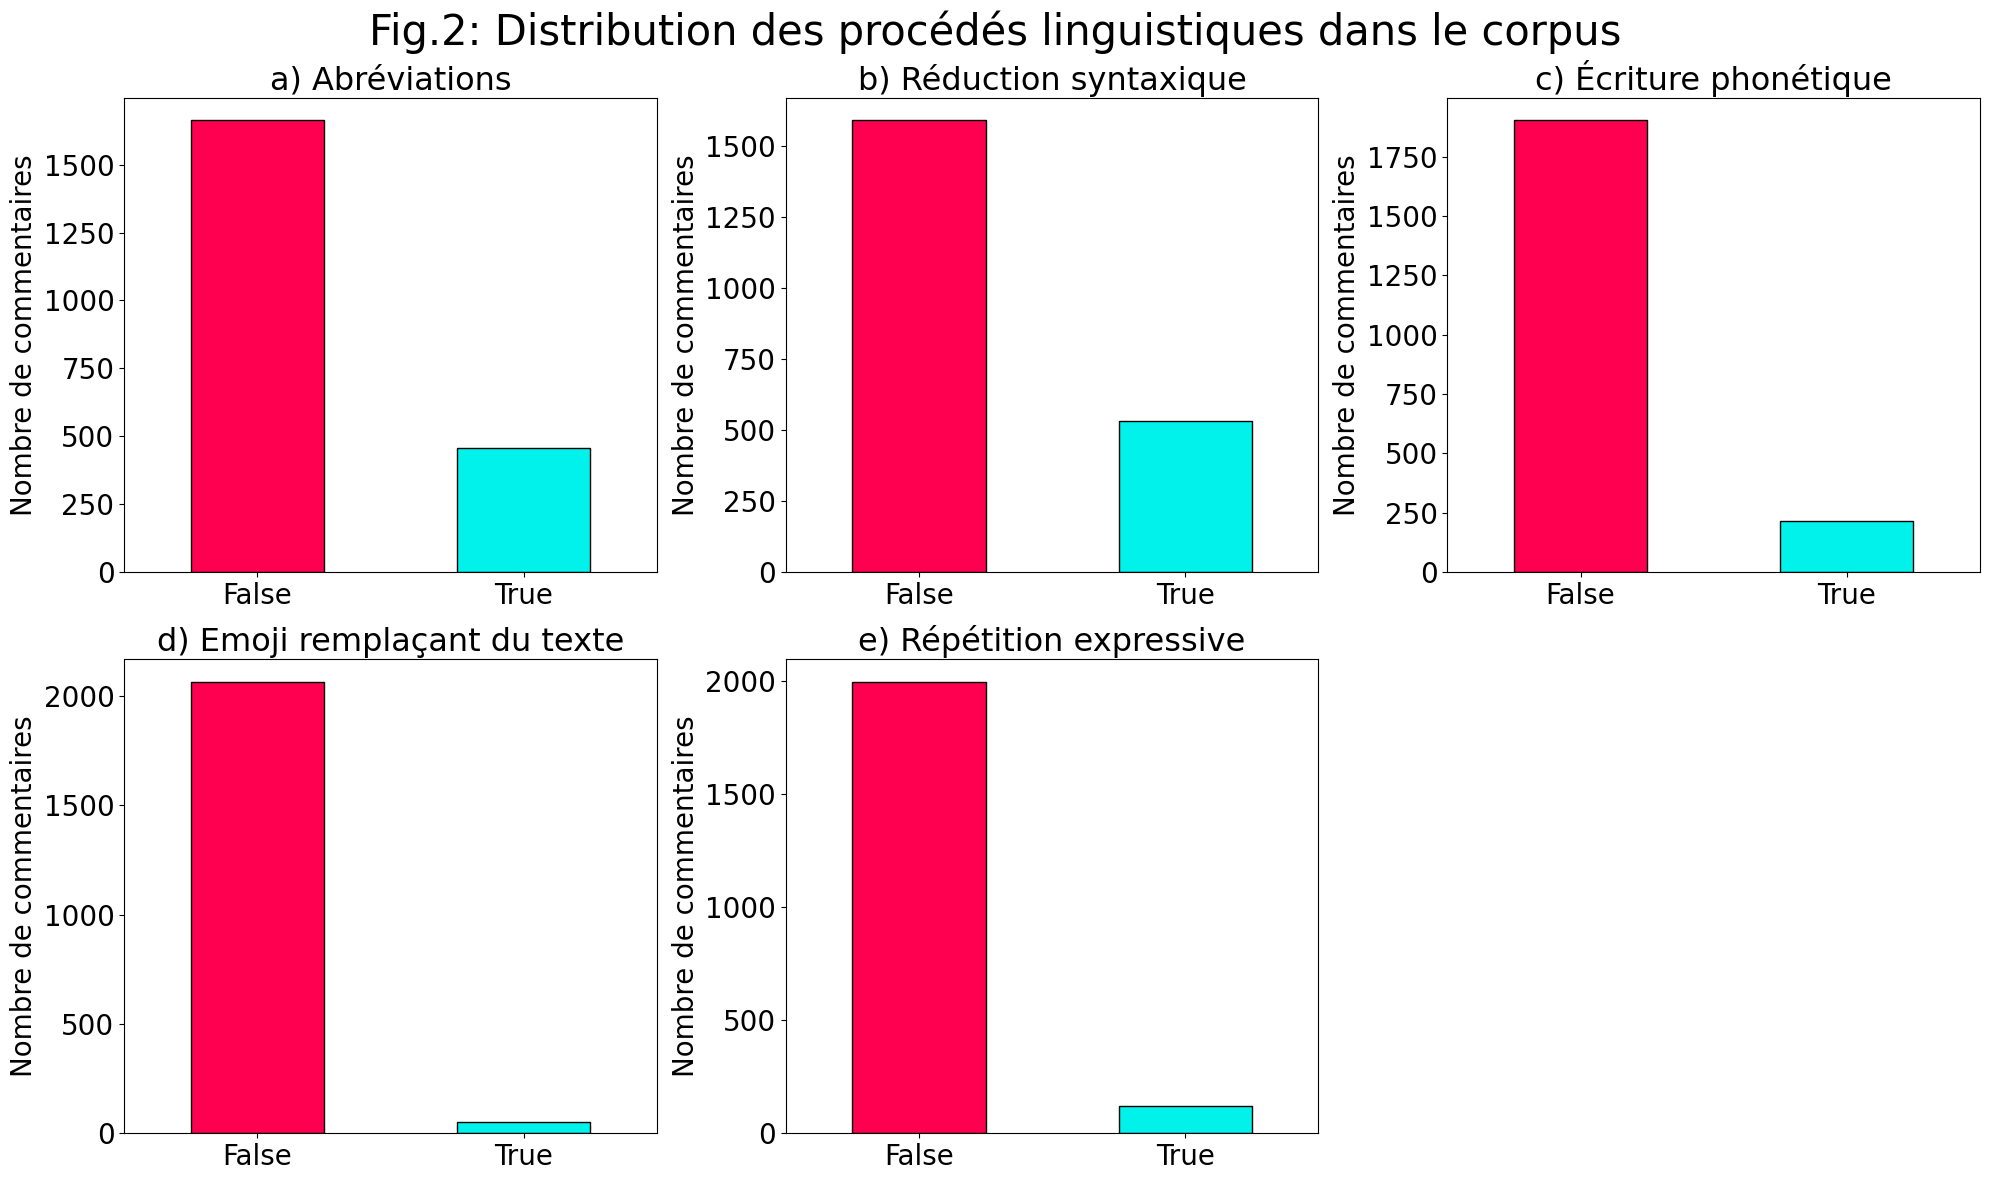

In [12]:
variables = [ # Variables linguistiques à représenter dans le graphique 2

    "abbreviation_words",
    "syntax_suppression",
    "phonetic_writing",
    "emoji_replaces_text",
    "letter_repetition_emotion"

]
titres = [ # Titres des graphiques

    "a) Abréviations",
    "b) Réduction syntaxique",
    "c) Écriture phonétique",
    "d) Emoji remplaçant du texte",
    "e) Répétition expressive"

]

fig, axes = plt.subplots( # Grand panel 
    2,
    3,
    figsize=(20,12),
)

axes = axes.flatten()


for i,var in enumerate(variables): # Boucle pour chaque graphique

    df[var].value_counts().sort_index().plot(

    kind="bar",
    ax=axes[i],
    edgecolor="black",
    color=["#ff0050", "#00f2ea"]

)

    axes[i].set_title(
        titres[i],
        fontsize=23
    )
    axes[i].set_xlabel(
        "",
        fontsize=16
    )
    axes[i].set_ylabel(
        "Nombre de commentaires",
        fontsize=20
    )
    axes[i].set_xticks(
        [0,1]
    )
    axes[i].set_xticklabels(
        ["False","True"],
        fontsize=20,
        rotation=0
    )
    axes[i].tick_params(
        axis='y',
        labelsize=20
    )

fig.delaxes(axes[5]) # Retirer le panneau vide

plt.suptitle(
    "Fig.2: Distribution des procédés linguistiques dans le corpus",
    fontsize=30
)

plt.tight_layout()
plt.show()

### 3.3 Analyse statistique

##### 3.3.1 Longueur x Economie linguistique

Hypothèses statistiques :
$$
H_0 :
\rho = 0
$$

Il n'existe aucune association entre la longueur des commentaires et l'indice d'économie linguistique.

$$
H_1 :
\rho < 0
$$

Il existe une association négative entre longueur et économie linguistique : les commentaires plus courts présentent davantage de phénomènes d'économie linguistique.

Les données linguistiques étant souvent non normales et asymétriques, on utilise une corrélation de Spearman. Le test de Spearman mesure une association monotone entre deux variables sans supposer une distribution normale.

In [ ]:
corr,p=spearmanr( # Test de Spearman
df["nb_mots"],
df["IEL"]
)

print(corr) # Affichage des résultats
print(p)

0.11876103769537168
4.180130398634969e-08


##### 3.3.2 Emojis x Economie linguistique

Hypothèses statistiques :

$$
H_0 :
F_{\text{emoji}} = F_{\text{sans emoji}}
$$

Les distributions des deux groupes sont identiques.

$$
H_1 :
F_{\text{emoji}} > F_{\text{sans emoji}}
$$

Les commentaires contenant des emojis présentent davantage de phénomènes d'économie linguistique.

On fait un test de Mann–Whitney.

In [ ]:
avec=df[ # Catégories avec/sans
df["emoji_replaces_text"]==1
]["IEL"]

sans=df[
df["emoji_replaces_text"]==0
]["IEL"]

stat,p=mannwhitneyu( # Test de Mann-Whitney
avec,
sans
)

print(stat) # Affichage des résultats
print(p)

86204.5
8.906575363128109e-17


##### 3.3.3 Abreviation x Supression syntaxique

Hypothèses statistiques :

$$
H_0 :
P(A \cap S)=P(A)P(S)
$$
Les deux phénomènes sont indépendants.


$$
H_1 :
P(A \cap S)\neq P(A)P(S)
$$
Les deux phénomènes ne sont pas indépendants et apparaissent ensemble plus souvent que ce qui serait attendu par hasard.


On fait un test de Khi² d’indépendance

In [ ]:
table=pd.crosstab( # Test de Khi
df["abbreviation_words"],
df["syntax_suppression"]
)

chi2,p,dof,expected=chi2_contingency(table)

print(chi2) # Affichage des résultats
print(p)

29.43101933956232
5.794274885419751e-08


##### 3.3.4 Répétitions x Longueur

Hypothèses statistiques :

$$
H_0 :
F_{\text{répétition}} = F_{\text{sans répétition}}
$$

Les distributions des longueurs des deux groupes sont identiques.

$$
H_1 :
F_{\text{répétition}} > F_{\text{sans répétition}}
$$

Les commentaires contenant des répétitions expressives tendent à être plus longs.

On fait un test de Mann–Whitney.

In [ ]:
avec=df[ # Catégories avec/sans
df["letter_repetition_emotion"]==1
]["nb_caracteres"]

sans=df[
df["letter_repetition_emotion"]==0
]["nb_caracteres"]

stat,p=mannwhitneyu( # Test de Mann-Whitney
avec,
sans
)

print(stat) # Affichage des résultats
print(p)

106428.5
0.01898433950365293


## **4. Résultats & Conclusion**

L’analyse statistique réalisée sur le corpus de commentaires TikTok met en évidence plusieurs tendances importantes concernant cette nouvelle langue des réseaux sociaux. La **Figure 1** montre que les commentaires du corpus sont majoritairement courts, ce qui confirme que les interactions sur les réseaux sociaux privilégient généralement des formats d’écriture rapides et concis.

Le premier test statistique, basé sur une corrélation de Spearman entre la longueur des commentaires et l’indice IEL, montre une corrélation positive faible mais statistiquement significative :

- coefficient de corrélation :
  
$$
\rho = 0.119
$$

- p-value :

$$
p = 4.18 \times 10^{-8}
$$

Contrairement à l’hypothèse initiale, **les commentaires les plus courts ne présentent donc pas davantage de phénomènes d’économie linguistique**. Les commentaires légèrement plus longs peuvent au contraire combiner plusieurs procédés simultanément.

Le deuxième test, un Mann–Whitney comparant les commentaires contenant des emojis à ceux n’en contenant pas, révèle une différence statistiquement significative :

- statistique du test :

$$
U = 86204.5
$$

- p-value :

$$
p = 8.91 \times 10^{-17}
$$

Les commentaires **avec emojis présentent davantage de phénomènes d’économie linguistique**. Les emojis semblent ainsi jouer un rôle linguistique important en condensant certaines informations émotionnelles ou pragmatiques dans une unité graphique très courte.

Le test du Khi² d’indépendance montre également que les abréviations et les réductions syntaxiques ne sont pas indépendantes :

- statistique du test :
$$
\chi^2 = 29.43
$$

- p-value :
$$
p = 5.79 \times 10^{-8}
$$

Ces procédés **apparaissent ensemble plus souvent que ce qui serait attendu par hasard**. L’économie linguistique semble donc fonctionner comme une stratégie globale mobilisant plusieurs mécanismes simultanément.

Enfin, le dernier test de Mann–Whitney montre que les commentaires contenant des répétitions expressives sont significativement plus longs :

- statistique du test :

$$
U = 106428.5
$$

- p-value :

$$
p = 0.019
$$

Ce résultat nuance l’idée d’une logique purement économique. **Les répétitions expressives augmentent la longueur du message** afin de renforcer l’intensité émotionnelle ou expressive.

Dans l’ensemble, les résultats montrent que **les pratiques linguistiques numériques des jeunes suivent effectivement certains principes d’économie linguistique** : abréviations, suppressions syntaxiques, oralisation ou compression pragmatique par emojis. Cependant, cette économie ne correspond **pas à un simple appauvrissement de la langue ni à une réduction systématique des messages**. Les utilisateurs développent plutôt des **stratégies** permettant de concilier rapidité d’écriture, expressivité et efficacité communicationnelle. Les réseaux sociaux apparaissent ainsi comme **un espace d’innovation linguistique** où les contraintes du médium numérique favorisent l’émergence de **nouvelles formes de communication** adaptées aux usages contemporains.